# Mumbai Street Annotations Analysis

Analysis of Label Studio annotations for Mumbai street images.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading & Cleaning

In [2]:
with open('../../labelstudio/mumbai_export_221408_project-221408-at-2026-02-02-21-33-2247d6c5.json', 'r') as f:
    data = json.load(f)

print(f"Total images: {len(data)}")

Total images: 2863


In [3]:
def parse_annotation(task, annotation):
    """Parse a single annotation into a flat dict."""
    row = {
        'task_id': task['id'],
        'annotation_id': annotation['id'],
        'annotator_email': annotation['completed_by']['email'],
        'image': task['data']['image'],
        'file_upload': task.get('file_upload', ''),
    }
    
    for result in annotation['result']:
        field_name = result['from_name']
        if result['type'] == 'taxonomy':
            value = result['value']['taxonomy'][0][0] if result['value']['taxonomy'] else None
        elif result['type'] == 'choices':
            value = result['value']['choices'][0] if result['value']['choices'] else None
        elif result['type'] == 'textarea':
            value = result['value']['text'][0] if result['value']['text'] else None
        else:
            value = None
        row[field_name] = value
    
    return row

rows = []
for task in data:
    for annotation in task['annotations']:
        rows.append(parse_annotation(task, annotation))

df = pd.DataFrame(rows)
print(f"Total annotations: {len(df)}")

Total annotations: 2875


In [4]:
core_fields = ['men_count', 'women_count', 'men_twowheeler', 'women_twowheeler', 
               'footpath', 'lane_markings', 'potholes', 'litter']
skip_fields = ['bus_station', 'railway_station', 'street_vendor']

def is_skip_row(row):
    """Check if row only has skip fields filled (and all are 'No')."""
    has_core = any(pd.notna(row.get(f)) for f in core_fields if f in row.index)
    has_skip = all(
        f in row.index and pd.notna(row.get(f)) and row.get(f) == 'No' 
        for f in skip_fields
    )
    return (not has_core) and has_skip

skip_mask = df.apply(is_skip_row, axis=1)
print(f"Skip rows (incomplete annotations): {skip_mask.sum()}")
print(f"Valid annotations: {(~skip_mask).sum()}")

df_valid = df[~skip_mask].copy()

Skip rows (incomplete annotations): 131
Valid annotations: 2744


In [5]:
count_cols = ['men_count', 'women_count', 'men_twowheeler', 'women_twowheeler']

def convert_count(val):
    if pd.isna(val):
        return np.nan
    if val == '>10':
        return 11
    try:
        return int(val)
    except (ValueError, TypeError):
        return np.nan

for col in count_cols:
    if col in df_valid.columns:
        df_valid[col] = df_valid[col].apply(convert_count)

df_valid[count_cols].head(10)

,men_count,women_count,men_twowheeler,women_twowheeler
0,3.0,2.0,4.0,NaN
2,NaN,NaN,1.0,NaN
3,8.0,7.0,2.0,1.0
4,11.0,1.0,2.0,NaN
5,4.0,2.0,NaN,NaN
6,1.0,1.0,1.0,NaN
7,2.0,NaN,1.0,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN
10,3.0,4.0,NaN,NaN


## 2. Summary Statistics

In [6]:
print(f"Total images: {df_valid['task_id'].nunique()}")
print(f"Total valid annotations: {len(df_valid)}")
print(f"Unique annotators: {df_valid['annotator_email'].nunique()}")

Total images: 2740
Total valid annotations: 2744
Unique annotators: 3


In [7]:
multi_annotated = df_valid.groupby('task_id').size()
multi_annotated = multi_annotated[multi_annotated > 1]
print(f"Images with multiple annotations: {len(multi_annotated)}")
if len(multi_annotated) > 0:
    print(f"Annotation counts: {multi_annotated.value_counts().to_dict()}")

Images with multiple annotations: 3
Annotation counts: {2: 2, 3: 1}


In [8]:
all_fields = core_fields + skip_fields
completion_rates = {}
for field in all_fields:
    if field in df_valid.columns:
        completion_rates[field] = df_valid[field].notna().mean() * 100

completion_df = pd.DataFrame.from_dict(completion_rates, orient='index', columns=['Completion %'])
completion_df = completion_df.sort_values('Completion %', ascending=False)
print("Field Completion Rates:")
print(completion_df.round(1))

Field Completion Rates:
                  Completion %
bus_station              100.0
railway_station          100.0
street_vendor            100.0
men_count                 79.4
footpath                  70.6
men_twowheeler            63.7
lane_markings             59.5
women_count               42.2
women_twowheeler          13.7
litter                    12.0
potholes                   2.7


In [9]:
annotator_counts = df_valid['annotator_email'].value_counts()
print("Annotations by annotator:")
print(annotator_counts)

Annotations by annotator:
annotator_email
swathi@verifinity.ai    2714
varun.rama@usc.edu        29
gsood07@gmail.com          1
Name: count, dtype: int64


## 3. Gender Analysis

In [10]:
print("Count Statistics:")
print(df_valid[count_cols].describe().round(2))

Count Statistics:
       men_count  women_count  men_twowheeler  women_twowheeler
count    2180.00      1157.00         1749.00            377.00
mean        4.62         2.08            2.81              1.19
std         3.27         1.58            2.01              0.64
min         0.00         0.00            0.00              0.00
25%         2.00         1.00            1.00              1.00
50%         4.00         2.00            2.00              1.00
75%         7.00         3.00            4.00              1.00
max        11.00        11.00           11.00              5.00


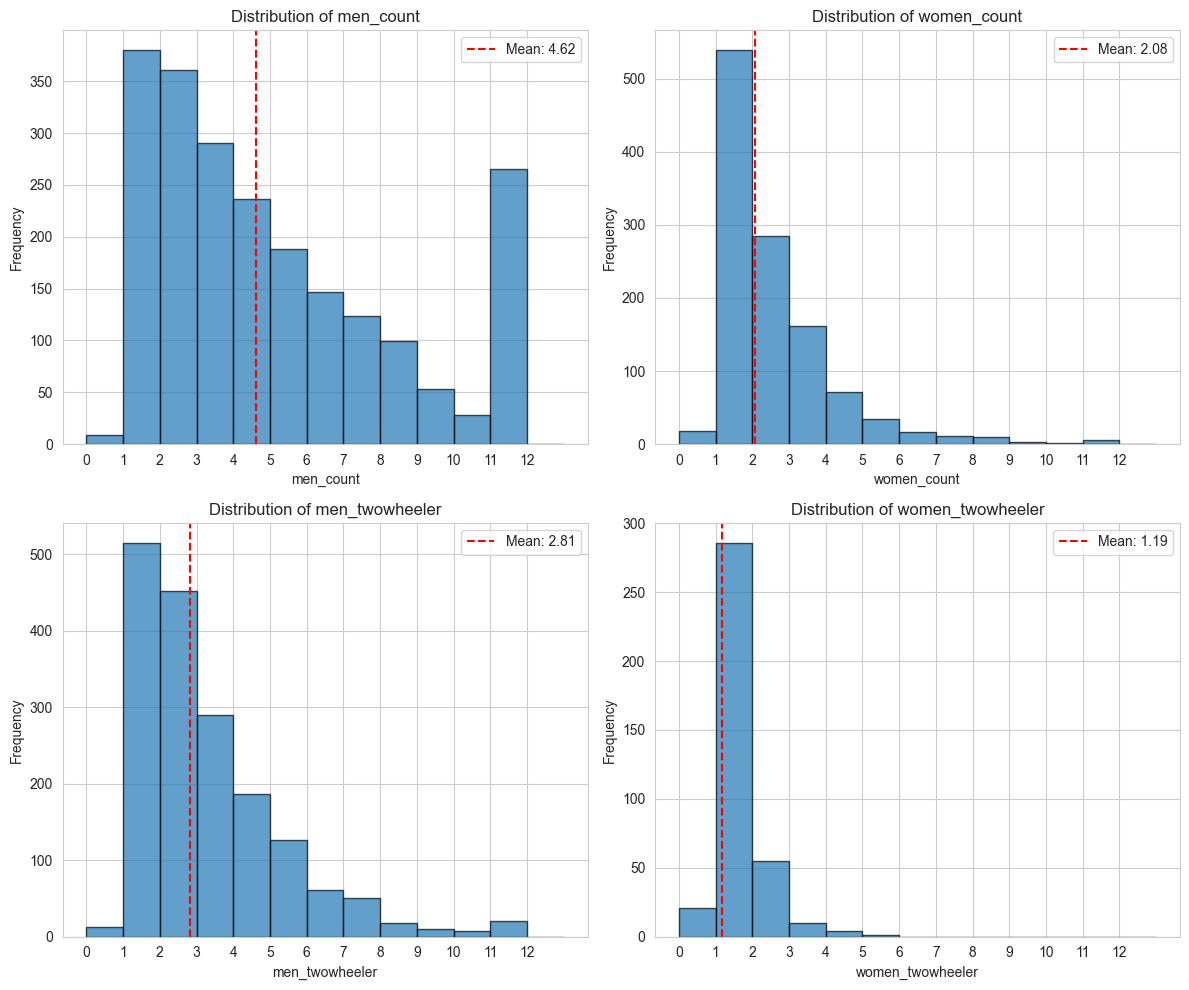

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flat, count_cols):
    if col in df_valid.columns:
        data_col = df_valid[col].dropna()
        ax.hist(data_col, bins=range(0, 14), edgecolor='black', alpha=0.7)
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.set_title(f'Distribution of {col}')
        ax.set_xticks(range(0, 13))
        ax.axvline(data_col.mean(), color='red', linestyle='--', label=f'Mean: {data_col.mean():.2f}')
        ax.legend()

plt.tight_layout()
plt.show()

In [12]:
df_valid['women_men_ratio'] = df_valid['women_count'] / df_valid['men_count'].replace(0, np.nan)
df_valid['women_men_twowheeler_ratio'] = df_valid['women_twowheeler'] / df_valid['men_twowheeler'].replace(0, np.nan)

print("Women/Men Ratio Statistics:")
print(f"  Pedestrians - Mean: {df_valid['women_men_ratio'].mean():.3f}, Median: {df_valid['women_men_ratio'].median():.3f}")
print(f"  Two-wheelers - Mean: {df_valid['women_men_twowheeler_ratio'].mean():.3f}, Median: {df_valid['women_men_twowheeler_ratio'].median():.3f}")

Women/Men Ratio Statistics:
  Pedestrians - Mean: 0.562, Median: 0.333
  Two-wheelers - Mean: 0.500, Median: 0.333


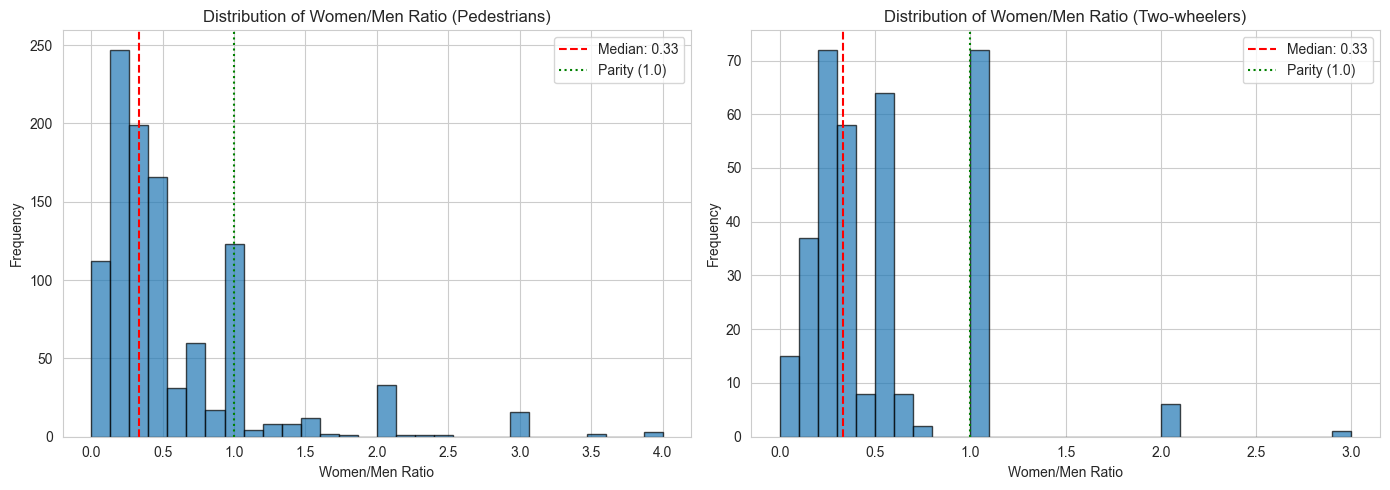

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratio_data = df_valid['women_men_ratio'].dropna()
ratio_data = ratio_data[ratio_data < 5]
axes[0].hist(ratio_data, bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Women/Men Ratio')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Women/Men Ratio (Pedestrians)')
axes[0].axvline(ratio_data.median(), color='red', linestyle='--', label=f'Median: {ratio_data.median():.2f}')
axes[0].axvline(1.0, color='green', linestyle=':', label='Parity (1.0)')
axes[0].legend()

ratio_tw = df_valid['women_men_twowheeler_ratio'].dropna()
ratio_tw = ratio_tw[ratio_tw < 5]
axes[1].hist(ratio_tw, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Women/Men Ratio')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Women/Men Ratio (Two-wheelers)')
axes[1].axvline(ratio_tw.median(), color='red', linestyle='--', label=f'Median: {ratio_tw.median():.2f}')
axes[1].axvline(1.0, color='green', linestyle=':', label='Parity (1.0)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
print("Zero Count Analysis:")
for col in count_cols:
    if col in df_valid.columns:
        zero_pct = (df_valid[col] == 0).mean() * 100
        print(f"  {col}: {zero_pct:.1f}% zeros")

Zero Count Analysis:
  men_count: 0.3% zeros
  women_count: 0.7% zeros
  men_twowheeler: 0.4% zeros
  women_twowheeler: 0.8% zeros


### 3A. Correlation Analysis

In [15]:
corr_cols = count_cols.copy()
df_corr = df_valid[corr_cols].dropna()

n = len(corr_cols)
corr_matrix = np.zeros((n, n))
pval_matrix = np.zeros((n, n))

for i, col1 in enumerate(corr_cols):
    for j, col2 in enumerate(corr_cols):
        valid_mask = df_corr[[col1, col2]].notna().all(axis=1)
        x, y = df_corr.loc[valid_mask, col1], df_corr.loc[valid_mask, col2]
        if len(x) > 2:
            r, p = stats.pearsonr(x, y)
            corr_matrix[i, j] = r
            pval_matrix[i, j] = p
        else:
            corr_matrix[i, j] = np.nan
            pval_matrix[i, j] = np.nan

corr_df = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols)
pval_df = pd.DataFrame(pval_matrix, index=corr_cols, columns=corr_cols)

print("Correlation Matrix:")
print(corr_df.round(3))
print("\nP-values:")
print(pval_df.round(4))

Correlation Matrix:
                  men_count  women_count  men_twowheeler  women_twowheeler
men_count             1.000        0.400           0.074             0.147
women_count           0.400        1.000           0.155             0.225
men_twowheeler        0.074        0.155           1.000             0.503
women_twowheeler      0.147        0.225           0.503             1.000

P-values:
                  men_count  women_count  men_twowheeler  women_twowheeler
men_count            0.0000       0.0000          0.3731            0.0737
women_count          0.0000       0.0000          0.0603            0.0059
men_twowheeler       0.3731       0.0603          0.0000            0.0000
women_twowheeler     0.0737       0.0059          0.0000            0.0000


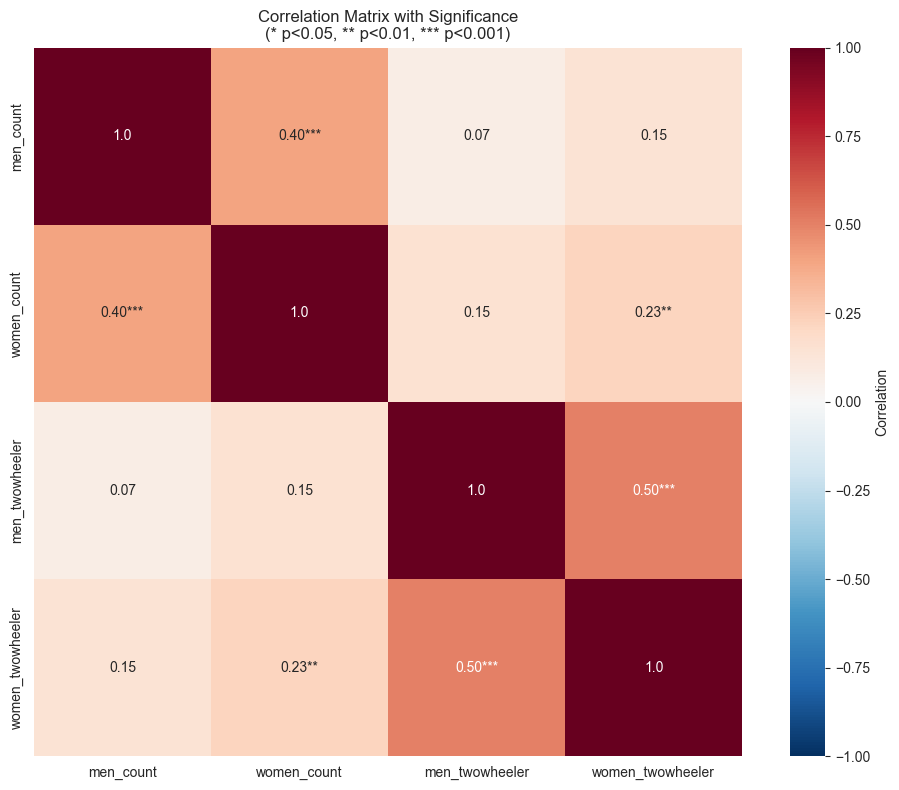

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)
annot_labels = corr_df.round(2).astype(str)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        if i != j:
            p = pval_df.iloc[i, j]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            annot_labels.iloc[i, j] = f"{corr_df.iloc[i, j]:.2f}{sig}"

sns.heatmap(corr_df, annot=annot_labels, fmt='', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix with Significance\n(* p<0.05, ** p<0.01, *** p<0.001)')
plt.tight_layout()
plt.show()

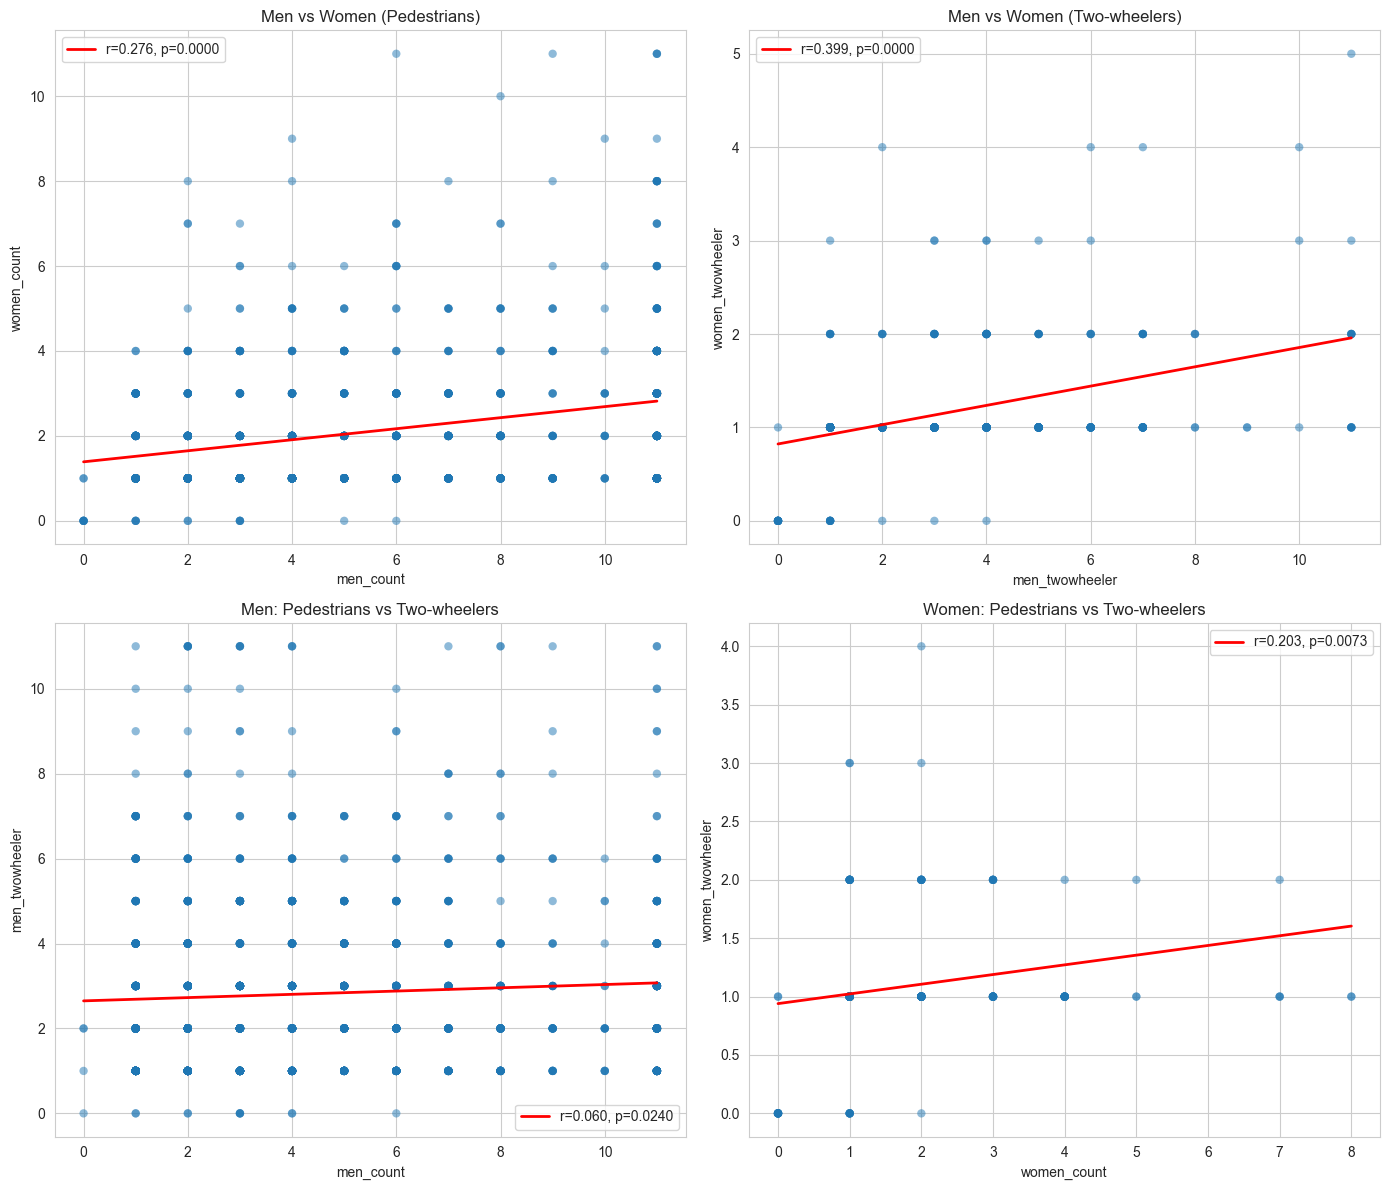

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter_pairs = [
    ('men_count', 'women_count', 'Men vs Women (Pedestrians)'),
    ('men_twowheeler', 'women_twowheeler', 'Men vs Women (Two-wheelers)'),
    ('men_count', 'men_twowheeler', 'Men: Pedestrians vs Two-wheelers'),
    ('women_count', 'women_twowheeler', 'Women: Pedestrians vs Two-wheelers'),
]

for ax, (x_col, y_col, title) in zip(axes.flat, scatter_pairs):
    valid = df_valid[[x_col, y_col]].dropna()
    x, y = valid[x_col], valid[y_col]
    
    ax.scatter(x, y, alpha=0.5, edgecolor='none')
    
    if len(x) > 2:
        r, p = stats.pearsonr(x, y)
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.array([x.min(), x.max()])
        ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2,
                label=f'r={r:.3f}, p={p:.4f}')
    
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

### 3B. Sex Ratio Analysis

Sex ratio defined as females per 1000 males (Indian demographic convention). Mumbai baseline: 838 (Census 2011).

In [18]:
MUMBAI_BASELINE_SEX_RATIO = 838

df_valid['sex_ratio_pedestrians'] = (df_valid['women_count'] / df_valid['men_count'].replace(0, np.nan)) * 1000
df_valid['sex_ratio_twowheelers'] = (df_valid['women_twowheeler'] / df_valid['men_twowheeler'].replace(0, np.nan)) * 1000

print("Sex Ratio Statistics (females per 1000 males):")
print(f"Mumbai Census 2011 baseline: {MUMBAI_BASELINE_SEX_RATIO}")
print(f"\nPedestrians:")
sr_ped = df_valid['sex_ratio_pedestrians'].dropna()
print(f"  Mean: {sr_ped.mean():.1f}, Median: {sr_ped.median():.1f}, Std: {sr_ped.std():.1f}")
print(f"  Min: {sr_ped.min():.1f}, Max: {sr_ped.max():.1f}")
print(f"\nTwo-wheelers:")
sr_tw = df_valid['sex_ratio_twowheelers'].dropna()
print(f"  Mean: {sr_tw.mean():.1f}, Median: {sr_tw.median():.1f}, Std: {sr_tw.std():.1f}")
print(f"  Min: {sr_tw.min():.1f}, Max: {sr_tw.max():.1f}")

Sex Ratio Statistics (females per 1000 males):
Mumbai Census 2011 baseline: 838

Pedestrians:
  Mean: 562.5, Median: 333.3, Std: 575.9
  Min: 0.0, Max: 4000.0

Two-wheelers:
  Mean: 499.9, Median: 333.3, Std: 393.0
  Min: 0.0, Max: 3000.0


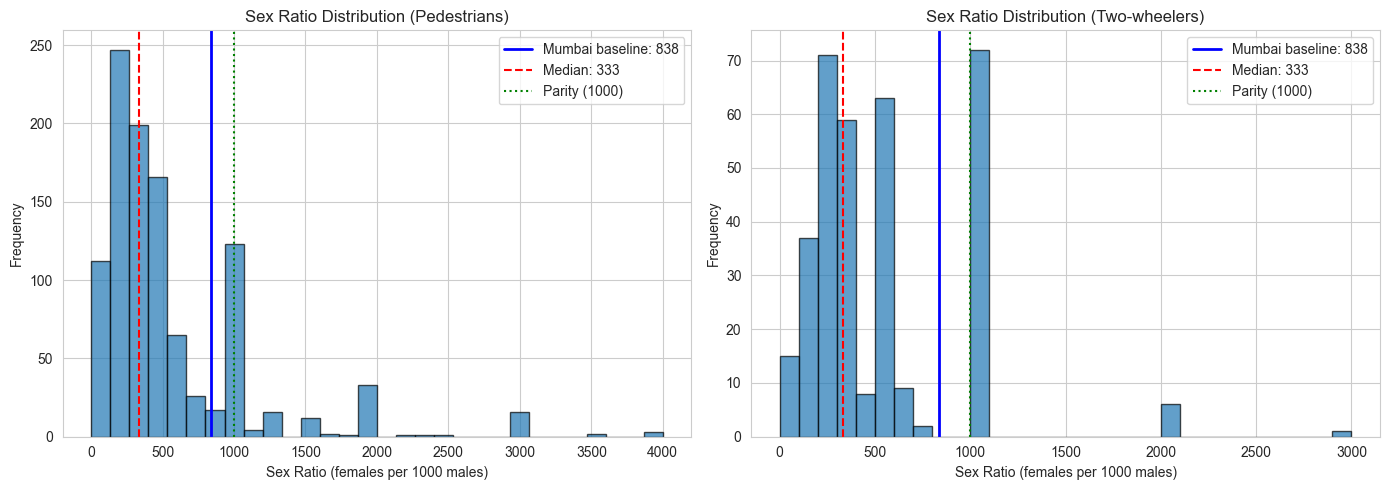

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sr_ped_plot = sr_ped[sr_ped < 5000]
axes[0].hist(sr_ped_plot, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(MUMBAI_BASELINE_SEX_RATIO, color='blue', linestyle='-', linewidth=2, 
                label=f'Mumbai baseline: {MUMBAI_BASELINE_SEX_RATIO}')
axes[0].axvline(sr_ped_plot.median(), color='red', linestyle='--', 
                label=f'Median: {sr_ped_plot.median():.0f}')
axes[0].axvline(1000, color='green', linestyle=':', label='Parity (1000)')
axes[0].set_xlabel('Sex Ratio (females per 1000 males)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sex Ratio Distribution (Pedestrians)')
axes[0].legend()

sr_tw_plot = sr_tw[sr_tw < 5000]
axes[1].hist(sr_tw_plot, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(MUMBAI_BASELINE_SEX_RATIO, color='blue', linestyle='-', linewidth=2,
                label=f'Mumbai baseline: {MUMBAI_BASELINE_SEX_RATIO}')
axes[1].axvline(sr_tw_plot.median(), color='red', linestyle='--',
                label=f'Median: {sr_tw_plot.median():.0f}')
axes[1].axvline(1000, color='green', linestyle=':', label='Parity (1000)')
axes[1].set_xlabel('Sex Ratio (females per 1000 males)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Sex Ratio Distribution (Two-wheelers)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
print("One-sample t-test against Mumbai baseline (838):")

t_ped, p_ped = stats.ttest_1samp(sr_ped, MUMBAI_BASELINE_SEX_RATIO)
print(f"\nPedestrians:")
print(f"  t-statistic: {t_ped:.3f}")
print(f"  p-value: {p_ped:.4f}")
print(f"  Significantly different from baseline: {'Yes' if p_ped < 0.05 else 'No'}")

t_tw, p_tw = stats.ttest_1samp(sr_tw, MUMBAI_BASELINE_SEX_RATIO)
print(f"\nTwo-wheelers:")
print(f"  t-statistic: {t_tw:.3f}")
print(f"  p-value: {p_tw:.4f}")
print(f"  Significantly different from baseline: {'Yes' if p_tw < 0.05 else 'No'}")

One-sample t-test against Mumbai baseline (838):

Pedestrians:
  t-statistic: -15.479
  p-value: 0.0000
  Significantly different from baseline: Yes

Two-wheelers:
  t-statistic: -15.935
  p-value: 0.0000
  Significantly different from baseline: Yes


### 3C. Busyness & Gender Proportion

In [21]:
df_valid['total_pedestrians'] = df_valid['men_count'] + df_valid['women_count']
df_valid['total_twowheelers'] = df_valid['men_twowheeler'] + df_valid['women_twowheeler']
df_valid['total_women'] = df_valid['women_count'] + df_valid['women_twowheeler']
df_valid['total_men'] = df_valid['men_count'] + df_valid['men_twowheeler']
df_valid['total_people'] = df_valid['total_pedestrians'] + df_valid['total_twowheelers']

df_valid['prop_women'] = df_valid['total_women'] / df_valid['total_people'].replace(0, np.nan)
df_valid['prop_women_pedestrians'] = df_valid['women_count'] / df_valid['total_pedestrians'].replace(0, np.nan)
df_valid['prop_women_twowheelers'] = df_valid['women_twowheeler'] / df_valid['total_twowheelers'].replace(0, np.nan)

print("Busyness Statistics:")
print(f"\nTotal People:")
tp = df_valid['total_people'].dropna()
print(f"  Mean: {tp.mean():.2f}, Median: {tp.median():.2f}, Std: {tp.std():.2f}")
print(f"  Min: {tp.min():.0f}, Max: {tp.max():.0f}")

print(f"\nTotal Pedestrians:")
tped = df_valid['total_pedestrians'].dropna()
print(f"  Mean: {tped.mean():.2f}, Median: {tped.median():.2f}")

print(f"\nTotal Two-wheelers:")
ttw = df_valid['total_twowheelers'].dropna()
print(f"  Mean: {ttw.mean():.2f}, Median: {ttw.median():.2f}")

Busyness Statistics:

Total People:
  Mean: 11.46, Median: 11.00, Std: 5.43
  Min: 1, Max: 26

Total Pedestrians:
  Mean: 7.65, Median: 7.00

Total Two-wheelers:
  Mean: 4.64, Median: 4.00


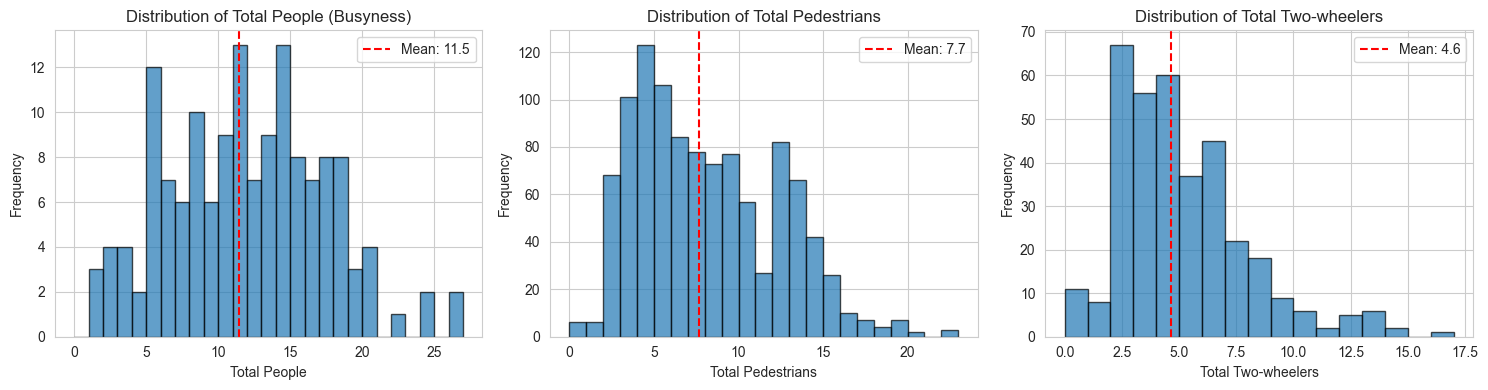

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(tp, bins=range(0, int(tp.max())+2), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Total People')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total People (Busyness)')
axes[0].axvline(tp.mean(), color='red', linestyle='--', label=f'Mean: {tp.mean():.1f}')
axes[0].legend()

axes[1].hist(tped, bins=range(0, int(tped.max())+2), edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Total Pedestrians')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Total Pedestrians')
axes[1].axvline(tped.mean(), color='red', linestyle='--', label=f'Mean: {tped.mean():.1f}')
axes[1].legend()

axes[2].hist(ttw, bins=range(0, int(ttw.max())+2), edgecolor='black', alpha=0.7)
axes[2].set_xlabel('Total Two-wheelers')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Total Two-wheelers')
axes[2].axvline(ttw.mean(), color='red', linestyle='--', label=f'Mean: {ttw.mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

In [23]:
print("Proportion Women Statistics:")
print(f"\nOverall (all people):")
pw = df_valid['prop_women'].dropna()
print(f"  Mean: {pw.mean():.3f}, Median: {pw.median():.3f}, Std: {pw.std():.3f}")

print(f"\nPedestrians only:")
pwp = df_valid['prop_women_pedestrians'].dropna()
print(f"  Mean: {pwp.mean():.3f}, Median: {pwp.median():.3f}, Std: {pwp.std():.3f}")

print(f"\nTwo-wheelers only:")
pwtw = df_valid['prop_women_twowheelers'].dropna()
print(f"  Mean: {pwtw.mean():.3f}, Median: {pwtw.median():.3f}, Std: {pwtw.std():.3f}")

Proportion Women Statistics:

Overall (all people):
  Mean: 0.258, Median: 0.250, Std: 0.137

Pedestrians only:
  Mean: 0.305, Median: 0.250, Std: 0.170

Two-wheelers only:
  Mean: 0.299, Median: 0.250, Std: 0.151


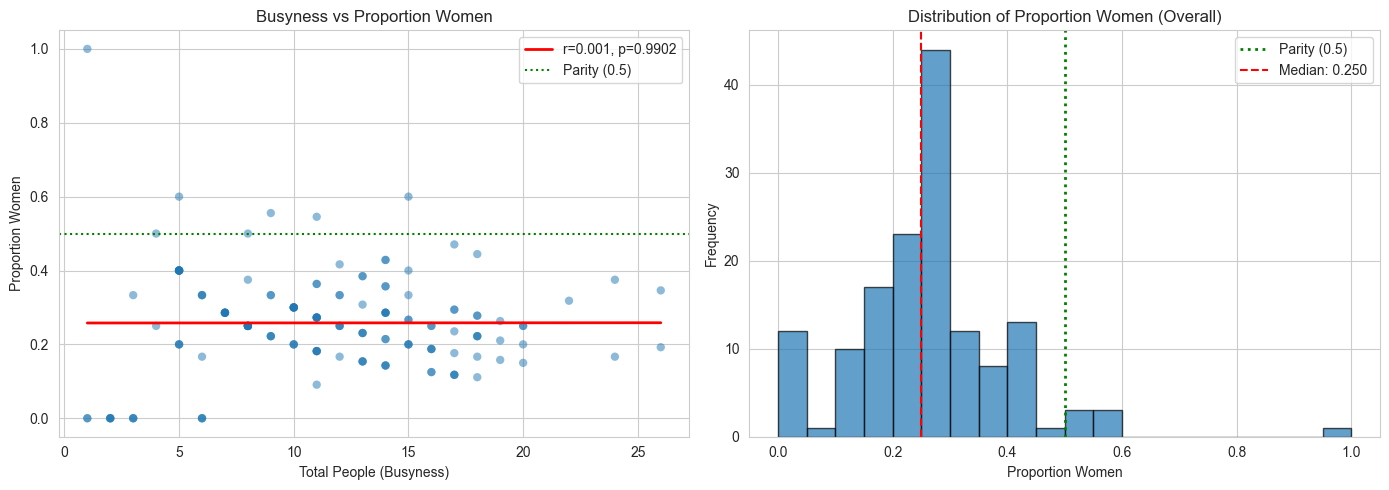

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_busy = df_valid[['total_people', 'prop_women']].dropna()
x, y = valid_busy['total_people'], valid_busy['prop_women']
axes[0].scatter(x, y, alpha=0.5, edgecolor='none')
if len(x) > 2:
    r, p = stats.pearsonr(x, y)
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.array([x.min(), x.max()])
    axes[0].plot(x_line, slope * x_line + intercept, 'r-', linewidth=2,
                 label=f'r={r:.3f}, p={p:.4f}')
axes[0].axhline(0.5, color='green', linestyle=':', label='Parity (0.5)')
axes[0].set_xlabel('Total People (Busyness)')
axes[0].set_ylabel('Proportion Women')
axes[0].set_title('Busyness vs Proportion Women')
axes[0].legend()

axes[1].hist(pw, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(0.5, color='green', linestyle=':', linewidth=2, label='Parity (0.5)')
axes[1].axvline(pw.median(), color='red', linestyle='--', label=f'Median: {pw.median():.3f}')
axes[1].set_xlabel('Proportion Women')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Proportion Women (Overall)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Infrastructure Analysis

In [25]:
categorical_fields = ['footpath', 'lane_markings', 'potholes', 'litter', 
                      'bus_station', 'railway_station', 'street_vendor']

for field in categorical_fields:
    if field in df_valid.columns:
        print(f"\n{field}:")
        counts = df_valid[field].value_counts(dropna=False)
        pcts = df_valid[field].value_counts(normalize=True, dropna=False) * 100
        for val in counts.index:
            print(f"  {val}: {counts[val]} ({pcts[val]:.1f}%)")


footpath:
  Paved: 1150 (41.9%)
  nan: 806 (29.4%)
  No sidewalk: 459 (16.7%)
  Paved - Blocked: 324 (11.8%)
  Not visible: 5 (0.2%)

lane_markings:
  Yes: 1602 (58.4%)
  nan: 1111 (40.5%)
  N/A: 19 (0.7%)
  No: 12 (0.4%)

potholes:
  nan: 2669 (97.3%)
  Yes: 30 (1.1%)
  No: 26 (0.9%)
  N/A: 19 (0.7%)

litter:
  nan: 2415 (88.0%)
  Yes: 256 (9.3%)
  Construction debris: 57 (2.1%)
  No: 16 (0.6%)

bus_station:
  No: 2650 (96.6%)
  Yes: 94 (3.4%)

railway_station:
  No: 2736 (99.7%)
  Yes: 8 (0.3%)

street_vendor:
  No: 2556 (93.1%)
  Yes: 187 (6.8%)
  nan: 1 (0.0%)


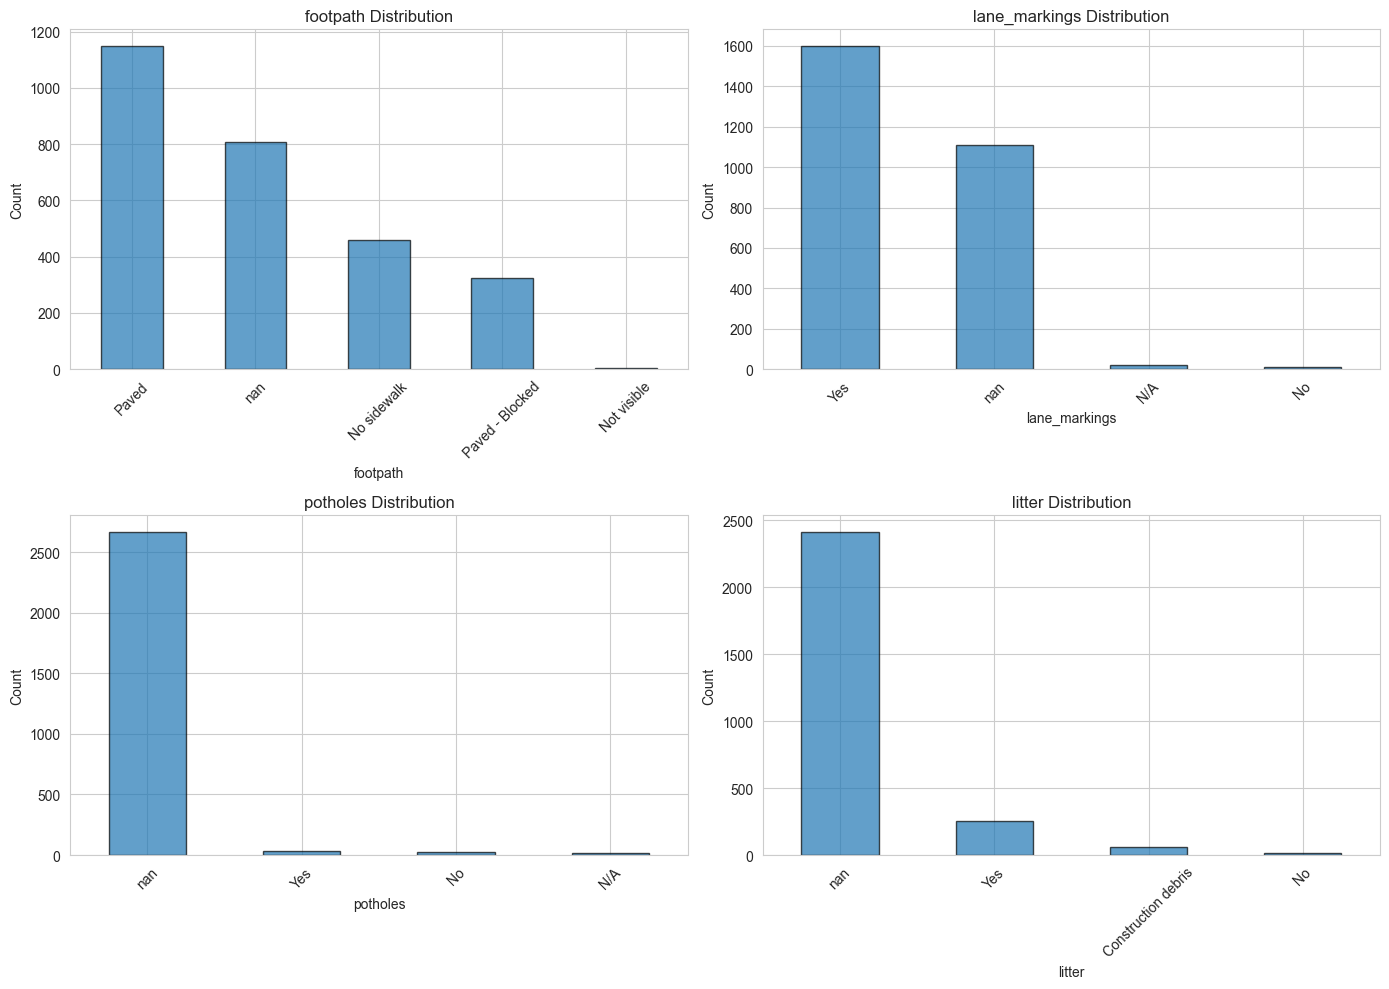

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

infra_fields = ['footpath', 'lane_markings', 'potholes', 'litter']
for ax, field in zip(axes.flat, infra_fields):
    if field in df_valid.columns:
        counts = df_valid[field].value_counts(dropna=False)
        counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{field} Distribution')
        ax.set_xlabel(field)
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

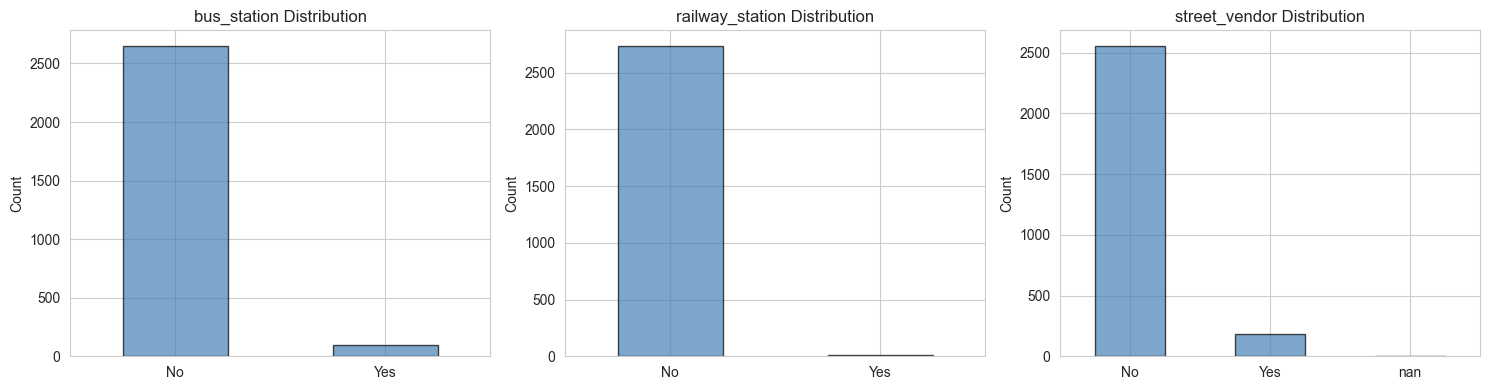

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

poi_fields = ['bus_station', 'railway_station', 'street_vendor']
for ax, field in zip(axes, poi_fields):
    if field in df_valid.columns:
        counts = df_valid[field].value_counts(dropna=False)
        counts.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7, color='steelblue')
        ax.set_title(f'{field} Distribution')
        ax.set_xlabel('')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4A. Gender by Infrastructure

In [28]:
print("Gender Metrics by Footpath Type:")
if 'footpath' in df_valid.columns:
    footpath_stats = df_valid.groupby('footpath').agg({
        'women_count': 'mean',
        'men_count': 'mean',
        'prop_women': 'mean',
        'sex_ratio_pedestrians': 'mean'
    }).round(3)
    footpath_stats.columns = ['Mean Women', 'Mean Men', 'Prop Women', 'Sex Ratio']
    print(footpath_stats)
    
    groups = [df_valid[df_valid['footpath'] == fp]['prop_women'].dropna() 
              for fp in df_valid['footpath'].dropna().unique()]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        h_stat, p_val = stats.kruskal(*groups)
        print(f"\nKruskal-Wallis test for prop_women by footpath:")
        print(f"  H-statistic: {h_stat:.3f}, p-value: {p_val:.4f}")

Gender Metrics by Footpath Type:
                 Mean Women  Mean Men  Prop Women  Sex Ratio
footpath                                                    
No sidewalk           2.183     5.426       0.283    541.329
Not visible           0.500     2.800       0.068    500.000
Paved                 1.906     4.195       0.245    573.507
Paved - Blocked       2.200     4.975       0.278    534.343

Kruskal-Wallis test for prop_women by footpath:
  H-statistic: 6.794, p-value: 0.0788


In [29]:
print("Gender Metrics by Potholes:")
if 'potholes' in df_valid.columns:
    pothole_stats = df_valid.groupby('potholes').agg({
        'women_count': 'mean',
        'men_count': 'mean',
        'prop_women': 'mean',
        'sex_ratio_pedestrians': 'mean'
    }).round(3)
    pothole_stats.columns = ['Mean Women', 'Mean Men', 'Prop Women', 'Sex Ratio']
    print(pothole_stats)
    
    yes_group = df_valid[df_valid['potholes'] == 'Yes']['prop_women'].dropna()
    no_group = df_valid[df_valid['potholes'] == 'No']['prop_women'].dropna()
    if len(yes_group) > 0 and len(no_group) > 0:
        u_stat, p_val = stats.mannwhitneyu(yes_group, no_group, alternative='two-sided')
        print(f"\nMann-Whitney U test for prop_women by potholes:")
        print(f"  U-statistic: {u_stat:.1f}, p-value: {p_val:.4f}")

print("\n" + "="*50)
print("\nGender Metrics by Litter:")
if 'litter' in df_valid.columns:
    litter_stats = df_valid.groupby('litter').agg({
        'women_count': 'mean',
        'men_count': 'mean',
        'prop_women': 'mean',
        'sex_ratio_pedestrians': 'mean'
    }).round(3)
    litter_stats.columns = ['Mean Women', 'Mean Men', 'Prop Women', 'Sex Ratio']
    print(litter_stats)
    
    yes_group = df_valid[df_valid['litter'] == 'Yes']['prop_women'].dropna()
    no_group = df_valid[df_valid['litter'] == 'No']['prop_women'].dropna()
    if len(yes_group) > 0 and len(no_group) > 0:
        u_stat, p_val = stats.mannwhitneyu(yes_group, no_group, alternative='two-sided')
        print(f"\nMann-Whitney U test for prop_women by litter:")
        print(f"  U-statistic: {u_stat:.1f}, p-value: {p_val:.4f}")

Gender Metrics by Potholes:
          Mean Women  Mean Men  Prop Women  Sex Ratio
potholes                                             
N/A            2.667     3.667         NaN    666.667
No             0.520     2.500       0.157    217.120
Yes            1.692     5.160         NaN    330.538


Gender Metrics by Litter:
                     Mean Women  Mean Men  Prop Women  Sex Ratio
litter                                                          
Construction debris       2.438     4.154         NaN    783.472
No                        0.625     3.000       0.123    242.063
Yes                       2.160     4.926       0.262    582.523

Mann-Whitney U test for prop_women by litter:
  U-statistic: 97.0, p-value: 0.2121


### 4B. Gender by POI (Points of Interest)

In [30]:
poi_fields = ['bus_station', 'railway_station', 'street_vendor']

for poi in poi_fields:
    if poi in df_valid.columns:
        print(f"\nGender Metrics by {poi}:")
        poi_stats = df_valid.groupby(poi).agg({
            'women_count': 'mean',
            'men_count': 'mean',
            'prop_women': 'mean',
            'total_people': 'mean'
        }).round(3)
        poi_stats.columns = ['Mean Women', 'Mean Men', 'Prop Women', 'Total People']
        print(poi_stats)
        
        yes_group = df_valid[df_valid[poi] == 'Yes']['prop_women'].dropna()
        no_group = df_valid[df_valid[poi] == 'No']['prop_women'].dropna()
        if len(yes_group) > 0 and len(no_group) > 0:
            u_stat, p_val = stats.mannwhitneyu(yes_group, no_group, alternative='two-sided')
            print(f"  Mann-Whitney U test: U={u_stat:.1f}, p={p_val:.4f}")
        print("-" * 40)


Gender Metrics by bus_station:
             Mean Women  Mean Men  Prop Women  Total People
bus_station                                                
No                2.079     4.593       0.260        11.312
Yes               2.077     5.277       0.239        13.500
  Mann-Whitney U test: U=617.0, p=0.5791
----------------------------------------

Gender Metrics by railway_station:
                 Mean Women  Mean Men  Prop Women  Total People
railway_station                                                
No                    2.078     4.604       0.258        11.459
Yes                   2.200     9.286         NaN           NaN
----------------------------------------

Gender Metrics by street_vendor:
               Mean Women  Mean Men  Prop Women  Total People
street_vendor                                                
No                  1.932     4.348       0.257        11.131
Yes                 3.127     7.597       0.267        13.833
  Mann-Whitney U test: U=1240.0

## 5. Inter-Annotator Agreement

In [31]:
multi_task_ids = multi_annotated.index.tolist()
print(f"Analyzing {len(multi_task_ids)} images with multiple annotators")

if len(multi_task_ids) > 0:
    df_multi = df_valid[df_valid['task_id'].isin(multi_task_ids)].copy()
    print(f"Total annotations for multi-annotated images: {len(df_multi)}")

Analyzing 3 images with multiple annotators
Total annotations for multi-annotated images: 7


In [32]:
if len(multi_task_ids) > 0:
    print("\nInter-Annotator Agreement for Count Fields:")
    for col in count_cols:
        if col in df_multi.columns:
            agreement_data = []
            for task_id in multi_task_ids:
                task_annots = df_multi[df_multi['task_id'] == task_id][col].dropna()
                if len(task_annots) >= 2:
                    diff = task_annots.max() - task_annots.min()
                    agreement_data.append(diff)
            if agreement_data:
                exact_match = sum(1 for d in agreement_data if d == 0)
                close_match = sum(1 for d in agreement_data if d <= 1)
                print(f"  {col}: Exact match {exact_match}/{len(agreement_data)} ({100*exact_match/len(agreement_data):.0f}%), "
                      f"Within 1: {close_match}/{len(agreement_data)} ({100*close_match/len(agreement_data):.0f}%)")


Inter-Annotator Agreement for Count Fields:
  men_count: Exact match 1/3 (33%), Within 1: 2/3 (67%)
  women_count: Exact match 1/1 (100%), Within 1: 1/1 (100%)
  men_twowheeler: Exact match 1/1 (100%), Within 1: 1/1 (100%)


In [33]:
if len(multi_task_ids) > 0:
    print("\nInter-Annotator Agreement for Categorical Fields:")
    for field in categorical_fields:
        if field in df_multi.columns:
            agreement_data = []
            for task_id in multi_task_ids:
                task_annots = df_multi[df_multi['task_id'] == task_id][field].dropna()
                if len(task_annots) >= 2:
                    agreement = len(task_annots.unique()) == 1
                    agreement_data.append(agreement)
            if agreement_data:
                agree_pct = 100 * sum(agreement_data) / len(agreement_data)
                print(f"  {field}: {sum(agreement_data)}/{len(agreement_data)} ({agree_pct:.0f}%) agreement")


Inter-Annotator Agreement for Categorical Fields:
  footpath: 1/2 (50%) agreement
  lane_markings: 1/1 (100%) agreement
  bus_station: 3/3 (100%) agreement
  railway_station: 3/3 (100%) agreement
  street_vendor: 2/3 (67%) agreement


## 6. Summary

In [34]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"\nDataset Overview:")
print(f"  Total images: {df_valid['task_id'].nunique()}")
print(f"  Total valid annotations: {len(df_valid)}")
print(f"  Skipped (incomplete) annotations: {skip_mask.sum()}")
print(f"  Unique annotators: {df_valid['annotator_email'].nunique()}")

print(f"\nGender Counts (means):")
for col in count_cols:
    if col in df_valid.columns:
        print(f"  {col}: {df_valid[col].mean():.2f}")

print(f"\nSex Ratios (females per 1000 males, Mumbai baseline: 838):")
print(f"  Pedestrians - Mean: {df_valid['sex_ratio_pedestrians'].mean():.1f}, Median: {df_valid['sex_ratio_pedestrians'].median():.1f}")
print(f"  Two-wheelers - Mean: {df_valid['sex_ratio_twowheelers'].mean():.1f}, Median: {df_valid['sex_ratio_twowheelers'].median():.1f}")

print(f"\nProportion Women:")
print(f"  Overall - Mean: {df_valid['prop_women'].mean():.3f}, Median: {df_valid['prop_women'].median():.3f}")
print(f"  Pedestrians - Mean: {df_valid['prop_women_pedestrians'].mean():.3f}")
print(f"  Two-wheelers - Mean: {df_valid['prop_women_twowheelers'].mean():.3f}")

print(f"\nBusyness:")
print(f"  Total people - Mean: {df_valid['total_people'].mean():.2f}, Median: {df_valid['total_people'].median():.2f}")

print(f"\nInfrastructure:")
if 'footpath' in df_valid.columns:
    paved_pct = ((df_valid['footpath'] == 'Paved') | (df_valid['footpath'] == 'Paved - Blocked')).mean() * 100
    no_sidewalk_pct = (df_valid['footpath'] == 'No sidewalk').mean() * 100
    print(f"  Paved footpath: {paved_pct:.1f}%")
    print(f"  No sidewalk: {no_sidewalk_pct:.1f}%")
if 'potholes' in df_valid.columns:
    pothole_pct = (df_valid['potholes'] == 'Yes').mean() * 100
    print(f"  Potholes present: {pothole_pct:.1f}%")
if 'litter' in df_valid.columns:
    litter_pct = (df_valid['litter'] == 'Yes').mean() * 100
    print(f"  Litter present: {litter_pct:.1f}%")

print(f"\nKey Correlations:")
valid_ped = df_valid[['men_count', 'women_count']].dropna()
valid_tw = df_valid[['men_twowheeler', 'women_twowheeler']].dropna()
r_ped, _ = stats.pearsonr(valid_ped['men_count'], valid_ped['women_count'])
r_tw, _ = stats.pearsonr(valid_tw['men_twowheeler'], valid_tw['women_twowheeler'])
print(f"  Men vs Women (pedestrians): r = {r_ped:.3f}")
print(f"  Men vs Women (two-wheelers): r = {r_tw:.3f}")

SUMMARY

Dataset Overview:
  Total images: 2740
  Total valid annotations: 2744
  Skipped (incomplete) annotations: 131
  Unique annotators: 3

Gender Counts (means):
  men_count: 4.62
  women_count: 2.08
  men_twowheeler: 2.81
  women_twowheeler: 1.19

Sex Ratios (females per 1000 males, Mumbai baseline: 838):
  Pedestrians - Mean: 562.5, Median: 333.3
  Two-wheelers - Mean: 499.9, Median: 333.3

Proportion Women:
  Overall - Mean: 0.258, Median: 0.250
  Pedestrians - Mean: 0.305
  Two-wheelers - Mean: 0.299

Busyness:
  Total people - Mean: 11.46, Median: 11.00

Infrastructure:
  Paved footpath: 53.7%
  No sidewalk: 16.7%
  Potholes present: 1.1%
  Litter present: 9.3%

Key Correlations:
  Men vs Women (pedestrians): r = 0.276
  Men vs Women (two-wheelers): r = 0.399
